# Bài 3 — Fine-tune Data-efficient Image Transformer (DeiT) trên Spectrogram

Sử dụng bộ dữ liệu **ESC-50** và biểu diễn **Log-Mel Spectrogram**. Fine-tune một mô hình **DeiT-Tiny pretrained trên ImageNet** cho bài toán phân loại 50 lớp âm thanh.

## Yêu cầu

1. Thích ứng **patch embedding** của DeiT từ đầu vào RGB 3 kênh sang Spectrogram 1 kênh, tận dụng trọng số pretrained.
2. Thay lớp **classification head** cho 50 lớp ESC-50.
3. Đóng băng phần lớn Transformer Encoder, chỉ fine-tune một vài **Encoder Block cuối** và lớp phân loại.
4. Huấn luyện, đánh giá và **so sánh kết quả với ResNet và CRNN** ở hai bài trước.

> Được phép dùng DeiT pretrained và Transformer Encoder có sẵn. Trọng tâm là **cross-modality transfer learning và selective fine-tuning**, không yêu cầu tự cài Multi-Head Attention hay tái hiện đầy đủ AST.

## 1. Setup

Để tập trung vào fine-tuning DeiT, notebook resize Log-Mel Spectrogram về `224 × 224`, đúng kích thước đầu vào chuẩn của DeiT-Tiny.

In [1]:
# Nếu chạy local và thiếu thư viện, cài trước:
# pip install torch torchvision torchaudio pandas matplotlib scikit-learn timm

from pathlib import Path
import copy
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED = 42
SAMPLE_RATE = 44_100
CLIP_SECONDS = 5
NUM_SAMPLES = SAMPLE_RATE * CLIP_SECONDS

N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 441          # xấp xỉ 100 frame/giây ở 44.1 kHz
NUM_CLASSES = 50

BATCH_SIZE = 32
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

Device: cuda


In [2]:
try:
    import timm
except ImportError as e:
    raise ImportError(
        "Thiếu thư viện timm. Kaggle/local hãy chạy: pip install timm"
    ) from e

## 2. Dataset và Log-Mel Spectrogram

In [3]:
from pathlib import Path
import urllib.request
import zipfile

DATASET_URL = "https://github.com/karoldvl/ESC-50/archive/master.zip"
ZIP_PATH = Path("esc50_master.zip")
LOCAL_DATA_ROOT = Path("ESC-50-master")

# Chỉ tải nếu dataset chưa tồn tại
if (LOCAL_DATA_ROOT / "meta" / "esc50.csv").exists():
    print(f"Dataset đã tồn tại tại: {LOCAL_DATA_ROOT.resolve()}")
else:
    print("Đang tải ESC-50 (~600 MB)...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)

    print("Đang giải nén...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(".")

    ZIP_PATH.unlink()  # Xóa file zip sau khi giải nén
    print(f"Hoàn tất. Dataset ở: {LOCAL_DATA_ROOT.resolve()}")

# Kiểm tra cấu trúc dữ liệu
assert (LOCAL_DATA_ROOT / "audio").exists()
assert (LOCAL_DATA_ROOT / "meta" / "esc50.csv").exists()

Dataset đã tồn tại tại: /content/ESC-50-master


In [4]:
from IPython.display import display
# =========================================================
# DATASET PATH — KAGGLE / MÁY CÁ NHÂN
# =========================================================
#
# Kaggle:
#   1) Add một dataset chứa ESC-50.
#   2) Notebook sẽ tự tìm file meta/esc50.csv trong /kaggle/input.
#
# Local:
#   Sửa LOCAL_DATA_ROOT thành thư mục ESC-50-master của bạn.
#   Cấu trúc mong đợi:
#       ESC-50-master/
#       ├── audio/
#       └── meta/esc50.csv
# =========================================================

LOCAL_DATA_ROOT = Path(r"./ESC-50-master")  # <-- Chỉ cần sửa dòng này khi chạy local.

def resolve_esc50_root():
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        matches = list(kaggle_input.glob("**/meta/esc50.csv"))
        if matches:
            root = matches[0].parent.parent
            print("Tìm thấy ESC-50 trên Kaggle:", root)
            return root

    if (LOCAL_DATA_ROOT / "meta" / "esc50.csv").exists():
        print("Dùng ESC-50 local:", LOCAL_DATA_ROOT)
        return LOCAL_DATA_ROOT

    raise FileNotFoundError(
        "Không tìm thấy ESC-50. Hãy Add Dataset trên Kaggle hoặc sửa LOCAL_DATA_ROOT."
    )

DATA_ROOT = resolve_esc50_root()
META_CSV = DATA_ROOT / "meta" / "esc50.csv"
AUDIO_DIR = DATA_ROOT / "audio"

metadata = pd.read_csv(META_CSV)
print("Số mẫu:", len(metadata))
display(metadata.head())

Dùng ESC-50 local: ESC-50-master
Số mẫu: 2000


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [5]:
# =========================================================
# PREPROCESSING: waveform -> Log-Mel Spectrogram
# =========================================================

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    f_min=0.0,
    f_max=SAMPLE_RATE / 2,
    power=2.0,
)

db_transform = torchaudio.transforms.AmplitudeToDB(stype="power")

class ESC50Dataset(Dataset):
    def __init__(self, dataframe, audio_dir, resize_to=None):
        self.df = dataframe.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.resize_to = resize_to

    def __len__(self):
        return len(self.df)

    @staticmethod
    def _fix_length(waveform):
        if waveform.shape[-1] < NUM_SAMPLES:
            waveform = F.pad(waveform, (0, NUM_SAMPLES - waveform.shape[-1]))
        else:
            waveform = waveform[..., :NUM_SAMPLES]
        return waveform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav_path = self.audio_dir / row["filename"]

        waveform, sr = torchaudio.load(wav_path)

        # ESC-50 là mono, nhưng vẫn xử lý an toàn nếu file có nhiều kênh.
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sr != SAMPLE_RATE:
            waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)

        waveform = self._fix_length(waveform)

        spec = mel_transform(waveform)
        spec = db_transform(spec)

        # Chuẩn hóa riêng từng spectrogram để ổn định fine-tuning.
        spec = (spec - spec.mean()) / (spec.std() + 1e-6)

        if self.resize_to is not None:
            spec = F.interpolate(
                spec.unsqueeze(0),
                size=self.resize_to,
                mode="bilinear",
                align_corners=False,
            ).squeeze(0)

        label = int(row["target"])
        return spec.float(), label

# Dùng fold chính thức của ESC-50 để ba notebook so sánh công bằng:
# Train: fold 1,2,3 | Validation: fold 4 | Test: fold 5
train_df = metadata[metadata["fold"].isin([1, 2, 3])].copy()
val_df   = metadata[metadata["fold"] == 4].copy()
test_df  = metadata[metadata["fold"] == 5].copy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 1200 | Val: 400 | Test: 400


/usr/local/lib/python3.13/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


Resized spectrogram: (1, 224, 224) | label: 0


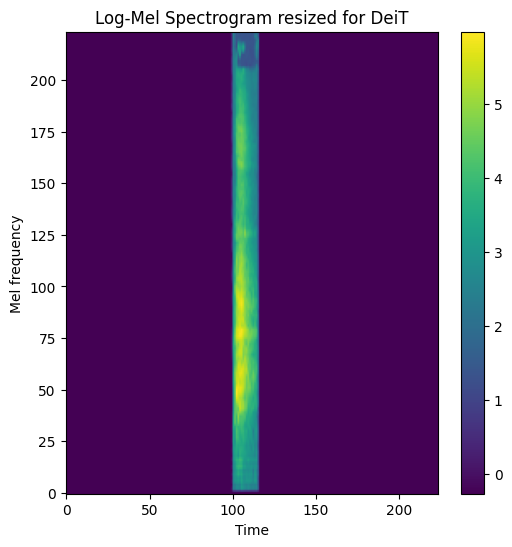

In [6]:
DEIT_INPUT_SIZE = (224, 224)

train_ds = ESC50Dataset(train_df, AUDIO_DIR, resize_to=DEIT_INPUT_SIZE)
val_ds   = ESC50Dataset(val_df, AUDIO_DIR, resize_to=DEIT_INPUT_SIZE)
test_ds  = ESC50Dataset(test_df, AUDIO_DIR, resize_to=DEIT_INPUT_SIZE)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

spec, label = train_ds[0]
print("Resized spectrogram:", tuple(spec.shape), "| label:", label)

plt.figure(figsize=(6, 6))
plt.imshow(spec.squeeze(0).numpy(), origin="lower", aspect="auto")
plt.title("Log-Mel Spectrogram resized for DeiT")
plt.xlabel("Time")
plt.ylabel("Mel frequency")
plt.colorbar()
plt.show()

## 3. DeiT-Tiny pretrained

Patch embedding của DeiT có thể xem như một convolution có `kernel_size = stride = patch_size`.

Mô hình pretrained nhận RGB 3 kênh. Với Spectrogram 1 kênh, ta tạo patch projection mới và khởi tạo trọng số bằng trung bình ba kênh RGB của projection pretrained.

In [7]:
def load_deit_tiny_pretrained():
    # Tương thích nhiều phiên bản timm.
    candidates = [
        "deit_tiny_patch16_224.fb_in1k",
        "deit_tiny_patch16_224",
    ]

    last_error = None
    for name in candidates:
        try:
            return timm.create_model(name, pretrained=True)
        except Exception as e:
            last_error = e

    raise RuntimeError(f"Không load được DeiT-Tiny pretrained: {last_error}")

def build_deit_for_spectrogram(num_classes=NUM_CLASSES):
    model = load_deit_tiny_pretrained()

    # Patch embedding is a Conv2d: average pretrained RGB filters into one channel.
    old_proj = model.patch_embed.proj
    new_proj = nn.Conv2d(
        in_channels=1,
        out_channels=old_proj.out_channels,
        kernel_size=old_proj.kernel_size,
        stride=old_proj.stride,
        padding=old_proj.padding,
        dilation=old_proj.dilation,
        groups=old_proj.groups,
        bias=old_proj.bias is not None,
    )
    with torch.no_grad():
        new_proj.weight.copy_(old_proj.weight.mean(dim=1, keepdim=True))
        if old_proj.bias is not None:
            new_proj.bias.copy_(old_proj.bias)
    model.patch_embed.proj = new_proj

    # Replace ImageNet's 1,000-class head with the ESC-50 classifier.
    model.head = nn.Linear(model.head.in_features, num_classes)
    return model

### Selective fine-tuning Transformer

Ta freeze phần lớn encoder và chỉ mở **2 block cuối**, normalization cuối và classification head.

In [8]:
def configure_deit_finetuning(model, num_unfrozen_blocks=2):
    if not 0 <= num_unfrozen_blocks <= len(model.blocks):
        raise ValueError(f"num_unfrozen_blocks must be in [0, {len(model.blocks)}].")

    # Freeze all pretrained parameters first.
    for parameter in model.parameters():
        parameter.requires_grad = False

    # Fine-tune only the last Transformer blocks, final norm, and new head.
    blocks_to_unfreeze = model.blocks[-num_unfrozen_blocks:] if num_unfrozen_blocks else []
    for block in blocks_to_unfreeze:
        for parameter in block.parameters():
            parameter.requires_grad = True
    for parameter in model.norm.parameters():
        parameter.requires_grad = True
    for parameter in model.head.parameters():
        parameter.requires_grad = True

    return model

set_seed()
model = build_deit_for_spectrogram()
model = configure_deit_finetuning(model, num_unfrozen_blocks=2).to(DEVICE)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            

## 4. Kiểm tra patch/token shape và output

In [9]:
x, _ = next(iter(train_loader))
x_small = x[:2].to(DEVICE)

with torch.no_grad():
    patch_tokens = model.patch_embed(x_small)
    logits = model(x_small)

print("Input        :", tuple(x_small.shape))
print("Patch tokens :", tuple(patch_tokens.shape))
print("Output logits:", tuple(logits.shape))

assert logits.shape == (2, NUM_CLASSES)

Input        : (2, 1, 224, 224)
Patch tokens : (2, 196, 192)
Output logits: (2, 50)


## 5. Huấn luyện và đánh giá

In [10]:
# =========================================================
# TRAIN / EVALUATE HELPERS
# =========================================================

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_targets = []
    all_preds = []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)

        total_correct += (preds == y).sum().item()
        total_samples += x.size(0)

        all_targets.extend(y.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "targets": all_targets,
        "preds": all_preds,
    }

def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -1.0
    best_state = None

    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_samples = 0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            running_samples += x.size(0)

        train_loss = running_loss / running_samples
        train_acc = running_correct / running_samples

        val_result = evaluate(model, val_loader, criterion)
        val_loss = val_result["loss"]
        val_acc = val_result["accuracy"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss={train_loss:.4f}, acc={train_acc:.4f} | "
            f"val loss={val_loss:.4f}, acc={val_acc:.4f}"
        )

    training_seconds = time.perf_counter() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_acc, training_seconds

def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()
    plt.show()

Total params: 5,435,762
Trainable params: 899,762
Epoch 01/10 | train loss=3.9741, acc=0.0275 | val loss=3.8134, acc=0.0575
Epoch 02/10 | train loss=3.6885, acc=0.0850 | val loss=3.5701, acc=0.1525
Epoch 03/10 | train loss=3.2349, acc=0.1758 | val loss=3.0321, acc=0.2450
Epoch 04/10 | train loss=2.5545, acc=0.3325 | val loss=2.6019, acc=0.3350
Epoch 05/10 | train loss=2.0402, acc=0.4967 | val loss=2.3242, acc=0.4000
Epoch 06/10 | train loss=1.6642, acc=0.6175 | val loss=2.1747, acc=0.4300
Epoch 07/10 | train loss=1.4084, acc=0.6825 | val loss=1.9975, acc=0.4525
Epoch 08/10 | train loss=1.1889, acc=0.7483 | val loss=1.9037, acc=0.4875
Epoch 09/10 | train loss=1.0049, acc=0.7925 | val loss=1.8078, acc=0.5150
Epoch 10/10 | train loss=0.8692, acc=0.8400 | val loss=1.7709, acc=0.5075


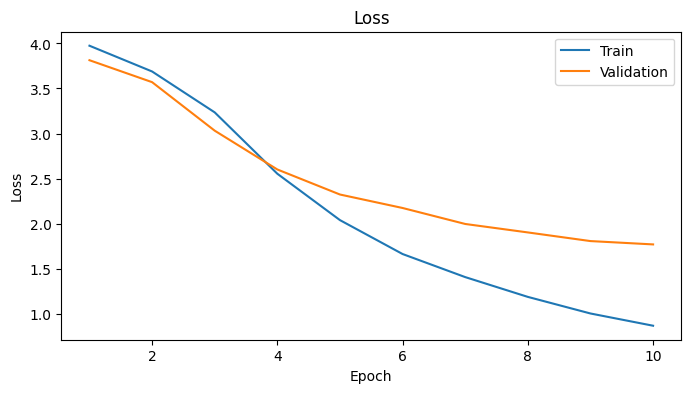

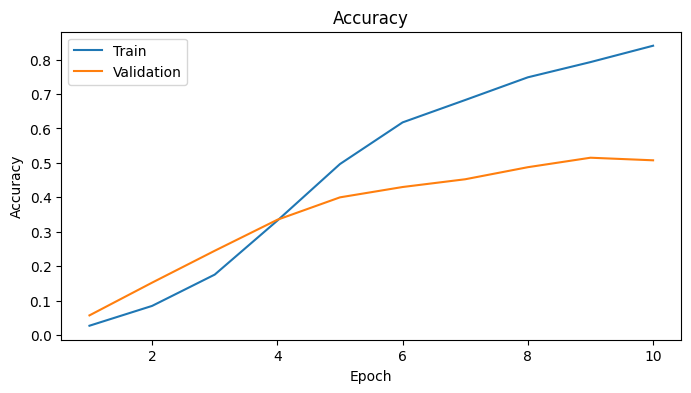

Best validation accuracy: 0.5150
Test accuracy: 0.5025
Training time (s): 251.60


In [11]:
EPOCHS = 10
LEARNING_RATE = 5e-5

set_seed()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

total_params, trainable_params = count_parameters(model)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

history, best_val_acc, training_seconds = train_model(
    model, train_loader, val_loader, optimizer, criterion, EPOCHS
)

torch.save(model.state_dict(), "deit_tiny_esc50_best.pt")

test_result = evaluate(model, test_loader, criterion)
plot_history(history)

print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Test accuracy: {test_result['accuracy']:.4f}")
print(f"Training time (s): {training_seconds:.2f}")

## 6. So sánh ResNet — CRNN — DeiT

Điền các số được in ra sau khi chạy từng notebook vào bảng dưới; không nên suy ra accuracy hoặc thời gian từ lý thuyết.

| Model | Test Accuracy | Trainable Parameters | Training Time |
|---|---:|---:|---:|
| ResNet18 | `test_accuracy` | `trainable_parameters` | `training_seconds` |
| CRNN | `test_accuracy` | `trainable_parameters` | `training_seconds` |
| DeiT-Tiny | `test_result['accuracy']` | `trainable_params` | `training_seconds` |

### Nhận xét

1. **ResNet** học đặc trưng cục bộ theo không gian 2D của spectrogram: cạnh, texture, formant/harmonic và các mẫu thời gian–tần số. Các tầng sâu ghép chúng thành đặc trưng âm thanh có mức trừu tượng cao hơn.
2. **GRU** nhận chuỗi đặc trưng từ CNN và giữ thông tin về thứ tự cùng ngữ cảnh theo thời gian. Vì vậy CRNN có thể phân biệt các âm có texture cục bộ giống nhau nhưng diễn tiến khác nhau.
3. **Self-Attention** cho mỗi patch tương tác trực tiếp với mọi patch khác trong cùng layer, nên có đường truyền thông tin ngắn cho quan hệ xa theo thời gian hoặc tần số. CRNN truyền ngữ cảnh xa tuần tự qua hidden state của GRU; nó có tính thứ tự tự nhiên hơn nhưng dễ thành nút thắt thông tin. Đổi lại attention có chi phí bộ nhớ/tính toán tăng theo bình phương số token.
4. **Không nhất thiết.** Accuracy phản ánh cả kiến trúc, pretrained weights, dữ liệu và siêu tham số; chi phí fine-tuning phụ thuộc số tham số mở khóa, kích thước input, batch size và phần cứng. Chọn mô hình theo cả accuracy, trainable parameters và training time trong bảng.
5. **Cách kết luận từ số đã chạy:** kết quả phù hợp với lý thuyết nếu CRNN cải thiện các lớp cần diễn tiến thời gian và DeiT có lợi khi quan hệ toàn cục hữu ích, nhưng DeiT không nhất thiết thắng trên ESC-50 nhỏ vì input spectrogram khác miền ImageNet và chỉ fine-tune hai block. Nếu ResNet/CRNN tốt hơn DeiT thì đây vẫn là kết quả hợp lý: inductive bias cục bộ/tuần tự và ít tham số trainable có thể phù hợp dữ liệu nhỏ hơn.